## NETWORK ANALYSIS

In [2]:

#  LOAD DATA & BASIC PREPROCESSING
# Preparing cleaned YouTube comments for vocabulary discovery.


import pandas as pd
import numpy as np
import re
from collections import Counter
from itertools import combinations


In [3]:
#  Load cleaned comments CSV


df = pd.read_csv("comments_cleaned.csv")

print(f"Rows loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Rows loaded: 6,241
Columns: ['video_id', 'video_title', 'author', 'comment_text', 'comment_published_at', 'comment_like_count', 'clean_comment', 'comment_length_chars', 'comment_length_words']


In [4]:
#  Keep useful columns only


keep_cols = [
    "video_id",
    "video_title",
    "author",
    "comment_published_at",
    "comment_like_count",
    "clean_comment"
]

keep_cols = [col for col in keep_cols if col in df.columns]

df = df[keep_cols].copy()


In [5]:
# Remove missing comments
df = df.dropna(subset=["clean_comment"]).reset_index(drop=True)

print(f"Rows after removing missing comments: {len(df):,}")


Rows after removing missing comments: 6,241


In [6]:
#  Create text column for network analysis


df["network_text"] = df["clean_comment"].astype(str).str.lower()

# Remove URLs
df["network_text"] = df["network_text"].str.replace(
    r"http\S+|www\S+", " ", regex=True
)

# Remove punctuation/special characters
df["network_text"] = df["network_text"].apply(
    lambda text: re.sub(r"[^a-zA-Z0-9\s]", " ", text)
)

# Remove extra spaces
df["network_text"] = df["network_text"].apply(
    lambda text: re.sub(r"\s+", " ", text).strip()
)

print("Basic preprocessing complete.")

df[["clean_comment", "network_text"]].head(10)

Basic preprocessing complete.


,clean_comment,network_text
0,nothing makes me feel older then watching a 15...,nothing makes me feel older then watching a 15...
1,6 x 7 = 42 the answer to life the universe and...,6 x 7 42 the answer to life the universe and e...
2,all i know is 6 is afraid of 7.,all i know is 6 is afraid of 7
3,having completely no context for it before thi...,having completely no context for it before thi...
4,"the next time my kid says ""6-7"", i'm going to ...",the next time my kid says 6 7 i m going to pun...
5,if someone says “6-7” i’m gonna say “10-4”,if someone says 6 7 i m gonna say 10 4
6,so it’s the linguistic equivalent of somebody ...,so it s the linguistic equivalent of somebody ...
7,a switch is a modification to a semiautomatic ...,a switch is a modification to a semiautomatic ...
8,"""you know what's funnier than 24? 25! 🤣🤣🤣"" - s...",you know what s funnier than 24 25 spongebob t...
9,"as a millenial, all this makes me think is, i ...",as a millenial all this makes me think is i ju...


In [7]:
## EXPLORATORY VOCABULARY DISCOVERY- Discovering important words and phrases from the actual comments.



In [8]:

# Define stopwords and generic words to remove


STOPWORDS = set("""
a an the and or but if because as until while of at by for with about against between into through during before after above below
to from up down in out on off over under again further then once here there when where why how all any both each few more most other
some such no nor not only own same so than too very can will just don should now is are was were be been being have has had do does did
this that these those i me my myself we our ours ourselves you your yours yourself yourselves he him his himself she her hers herself
it its itself they them their theirs themselves what which who whom whose am
""".split())

GENERIC_REMOVE = set("""
video videos watch watching watched good great thanks thank love really people thing things stuff make makes made get got like likes
think know say says said way see seen look looking lot much many one two also even still maybe actually probably literally basically
""".split())

REMOVE_WORDS = STOPWORDS | GENERIC_REMOVE




In [9]:
#  Tokenising comments

def tokenize(text):
    tokens = text.split()
    tokens = [
        token for token in tokens
        if token not in REMOVE_WORDS
        and len(token) > 2
        and not token.isnumeric()
    ]
    return tokens

df["tokens"] = df["network_text"].apply(tokenize)

print("Tokenisation complete.")
df[["network_text", "tokens"]].head(10)

Tokenisation complete.


,network_text,tokens
0,nothing makes me feel older then watching a 15...,"[nothing, feel, older, minute, breaking, slang..."
1,6 x 7 42 the answer to life the universe and e...,"[answer, life, universe, everything]"
2,all i know is 6 is afraid of 7,[afraid]
3,having completely no context for it before thi...,"[having, completely, context, thought, solo, v..."
4,the next time my kid says 6 7 i m going to pun...,"[next, time, kid, going, punish, making]"
5,if someone says 6 7 i m gonna say 10 4,"[someone, gonna]"
6,so it s the linguistic equivalent of somebody ...,"[linguistic, equivalent, somebody, getting, te..."
7,a switch is a modification to a semiautomatic ...,"[switch, modification, semiautomatic, firearm,..."
8,you know what s funnier than 24 25 spongebob t...,"[funnier, spongebob, amounts]"
9,as a millenial all this makes me think is i ju...,"[millenial, lost, game]"


In [10]:
##  WORD FREQUENCY ANALYSIS


In [11]:

all_tokens = [token for tokens in df["tokens"] for token in tokens]

word_freq = Counter(all_tokens)


# Top 150 words


top_words_150 = pd.DataFrame(
    word_freq.most_common(150),
    columns=["word", "frequency"]
)

print("Top 150 words:")
display(top_words_150)

Top 150 words:


,word,frequency
0,time,708
1,gen,546
2,brain,515
3,social,458
4,kids,447
...,...,...
145,isn,87
146,means,87
147,person,87
148,already,87


In [12]:

#  BIGRAM AND TRIGRAM DISCOVERY- this will help Identify common phrases such as social media, attention span, screen time.

In [13]:

def get_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

# Generate bigrams and trigrams
all_bigrams = []
all_trigrams = []

for tokens in df["tokens"]:
    all_bigrams.extend(get_ngrams(tokens, 2))
    all_trigrams.extend(get_ngrams(tokens, 3))

bigram_freq = Counter(all_bigrams)
trigram_freq = Counter(all_trigrams)

top_bigrams_100 = pd.DataFrame(
    [(" ".join(k), v) for k, v in bigram_freq.most_common(100)],
    columns=["bigram", "frequency"]
)

print("Top 100 bigrams:")
display(top_bigrams_100)
top_trigrams_100 = pd.DataFrame(
    [(" ".join(k), v) for k, v in trigram_freq.most_common(100)],
    columns=["trigram", "frequency"]
)

print("Top 100 trigrams:")
display(top_trigrams_100)

Top 100 bigrams:


,bigram,frequency
0,social media,381
1,brain rot,251
2,gen alpha,205
3,year old,82
4,attention span,81
...,...,...
95,past years,10
96,high quality,10
97,god bless,10
98,new slang,9


Top 100 trigrams:


,trigram,frequency
0,short form content,29
1,use social media,23
2,social media apps,20
3,gen alpha slang,17
4,deleted social media,14
...,...,...
95,mine high key,3
96,lag dead ass,3
97,night bad vibe,3
98,gonna yeet window,3


In [14]:

#  PHRASE STANDARDISATION-  Convert meaningful multi-word phrases into single concepts.


PHRASE_REPLACEMENTS = [

    
    # Platforms / media ecosystem
   

    (r"\bsocial media\b", "social_media"),
    (r"\bsocial media apps\b", "social_media_apps"),
    (r"\bsocial media platforms\b", "social_media_platforms"),

    (r"\byoutube shorts\b", "youtube_shorts"),

    (r"\btik tok\b", "tiktok"),
    (r"\btiktok\b", "tiktok"),

    (r"\bshort form content\b", "short_form_content"),
    (r"\bshort form\b", "short_form"),

    (r"\blong form content\b", "long_form_content"),
    (r"\blong form\b", "long_form"),

   
    # Cognitive / behavioural concepts
   

    (r"\bbrain rot\b", "brainrot"),
    (r"\bbrain rotting\b", "brainrot"),
    (r"\bbrainrot\b", "brainrot"),

    (r"\battention span\b", "attention_span"),
    (r"\bshort attention span\b", "short_attention_span"),

    (r"\bscreen time\b", "screen_time"),

    (r"\bdoom scrolling\b", "doomscrolling"),
    (r"\bmindlessly scrolling\b", "mindless_scrolling"),

    (r"\bmental health\b", "mental_health"),

    
    # Generation / youth discourse
   

    (r"\bgen alpha\b", "genalpha"),
    (r"\bgen z\b", "genz"),

    (r"\bgen alpha slang\b", "genalpha_slang"),
    (r"\balpha slang\b", "genalpha_slang"),

    (r"\bolder generations\b", "older_generations"),
    (r"\bnew generation\b", "new_generation"),

    (r"\bipad kids\b", "ipad_kids"),
    (r"\bipad kid\b", "ipad_kids"),

    
    # Meme / slang culture
   

    (r"\bskibidi toilet\b", "skibidi_toilet"),

    (r"\bfanum tax\b", "fanum_tax"),

    (r"\blow key\b", "lowkey"),
    (r"\blowkey\b", "lowkey"),

    (r"\bhigh key\b", "highkey"),
    (r"\bhighkey\b", "highkey"),

    (r"\bno cap\b", "nocap"),

    
    # Education / literacy / social
    

    (r"\bhigh school\b", "high_school"),
    (r"\bmiddle school\b", "middle_school"),

    (r"\bread books\b", "reading_books"),
    (r"\breading books\b", "reading_books"),

    (r"\benglish language\b", "english_language"),

    (r"\bsocial skills\b", "social_skills"),

]


# VOCABULARY REFINEMENT- Adding  missing high-value concepts discovered during exploration.

# Additional phrase replacements
ADDITIONAL_REPLACEMENTS = [

    # Behaviour / usage
    (r"\bsocial media use\b", "social_media_use"),
    (r"\busing social media\b", "social_media_use"),

    (r"\busing phone\b", "phone_use"),
    (r"\buse phone\b", "phone_use"),

    (r"\bscrolling social media\b", "social_media_scrolling"),

    (r"\bsocial media addiction\b", "social_media_addiction"),

    (r"\bmedia apps\b", "media_apps"),

    # Reading / literacy
    (r"\breading comprehension\b", "reading_comprehension"),

    # Behaviour
    (r"\binstant gratification\b", "instant_gratification"),

]
def standardise_phrases(text):

    for pattern, replacement in PHRASE_REPLACEMENTS:
        text = re.sub(pattern, replacement, text)

    return text

# First create concept_text
df["concept_text"] = df["network_text"].apply(standardise_phrases)

# Applying additional replacements
def apply_additional_replacements(text):

    for pattern, replacement in ADDITIONAL_REPLACEMENTS:
        text = re.sub(pattern, replacement, text)

    return text

df["concept_text"] = df["concept_text"].apply(
    apply_additional_replacements
)

print("Additional phrase refinement complete.")

# Applying phrase standardisation
df["concept_text"] = df["network_text"].apply(standardise_phrases)


print("Phrase standardisation complete.")

df[["network_text", "concept_text"]].head(10)

Additional phrase refinement complete.
Phrase standardisation complete.


,network_text,concept_text
0,nothing makes me feel older then watching a 15...,nothing makes me feel older then watching a 15...
1,6 x 7 42 the answer to life the universe and e...,6 x 7 42 the answer to life the universe and e...
2,all i know is 6 is afraid of 7,all i know is 6 is afraid of 7
3,having completely no context for it before thi...,having completely no context for it before thi...
4,the next time my kid says 6 7 i m going to pun...,the next time my kid says 6 7 i m going to pun...
5,if someone says 6 7 i m gonna say 10 4,if someone says 6 7 i m gonna say 10 4
6,so it s the linguistic equivalent of somebody ...,so it s the linguistic equivalent of somebody ...
7,a switch is a modification to a semiautomatic ...,a switch is a modification to a semiautomatic ...
8,you know what s funnier than 24 25 spongebob t...,you know what s funnier than 24 25 spongebob t...
9,as a millenial all this makes me think is i ju...,as a millenial all this makes me think is i ju...


In [15]:

#  CONTROLLED VOCABULARY


CONCEPT_THEMES = {

    
    # 1. Platforms / media environment
    

    "social_media": "platforms_media",
    "social_media_apps": "platforms_media",
    "social_media_platforms": "platforms_media",
    "youtube": "platforms_media",
    "youtube_shorts": "platforms_media",
    "tiktok": "platforms_media",
    "internet": "platforms_media",
    "online": "platforms_media",
    "platform": "platforms_media",
    "platforms": "platforms_media",
    "algorithm": "platforms_media",
    "algorithms": "platforms_media",

    
    # 2. Content format / media consumption
   

    "content": "content_format",
    "short_form": "content_format",
    "short_form_content": "content_format",
    "long_form": "content_format",
    "long_form_content": "content_format",
    "shorts": "content_format",
    "reels": "content_format",

   
    # 3. Cognitive impact / attention
  
    "brainrot": "cognitive_impact",
    "brain": "cognitive_impact",
    "rot": "cognitive_impact",
    "attention": "cognitive_impact",
    "attention_span": "cognitive_impact",
    "short_attention_span": "cognitive_impact",
    "focus": "cognitive_impact",
    "dopamine": "cognitive_impact",
    "addiction": "cognitive_impact",
    "addicted": "cognitive_impact",
    "addictive": "cognitive_impact",
    "doomscrolling": "cognitive_impact",
    "mindless_scrolling": "cognitive_impact",
    "mental_health": "cognitive_impact",

   
    # 4. Devices / screen use
    

    "phone": "devices_screen_use",
    "phones": "devices_screen_use",
    "screen": "devices_screen_use",
    "screens": "devices_screen_use",
    "screen_time": "devices_screen_use",
    "ipad": "devices_screen_use",
    "ipad_kids": "devices_screen_use",
    "tablet": "devices_screen_use",

   
    # 5. Generational / youth discourse
   

    "genalpha": "generation_youth",
    "genz": "generation_youth",
    "generation": "generation_youth",
    "new_generation": "generation_youth",
    "older_generations": "generation_youth",
    "kids": "generation_youth",
    "kid": "generation_youth",
    "children": "generation_youth",
    "child": "generation_youth",
    "teen": "generation_youth",
    "teenagers": "generation_youth",

   
    # 6. Meme / slang culture
    

    "slang": "meme_slang_culture",
    "genalpha_slang": "meme_slang_culture",
    "skibidi": "meme_slang_culture",
    "skibidi_toilet": "meme_slang_culture",
    "sigma": "meme_slang_culture",
    "rizz": "meme_slang_culture",
    "gyatt": "meme_slang_culture",
    "meme": "meme_slang_culture",
    "memes": "meme_slang_culture",
    "viral": "meme_slang_culture",
    "trend": "meme_slang_culture",
    "trends": "meme_slang_culture",
    "fanum_tax": "meme_slang_culture",
    "lowkey": "meme_slang_culture",
    "highkey": "meme_slang_culture",
    "nocap": "meme_slang_culture",

    
    # 7. Education / language / social life
  

    "school": "education_language",
    "high_school": "education_language",
    "middle_school": "education_language",
    "learning": "education_language",
    "learn": "education_language",
    "reading": "education_language",
    "reading_books": "education_language",
    "books": "education_language",
    "book": "education_language",
    "language": "education_language",
    "english_language": "education_language",
    "words": "education_language",
    "word": "education_language",
    "communication": "education_language",
    "conversation": "education_language",
    "understand": "education_language",
    "social_skills": "education_language",

    
    # 8. Parenting / social concern
   

    "parents": "parenting_social_concern",
    "parent": "parenting_social_concern",
    "childhood": "parenting_social_concern",
    "development": "parenting_social_concern",
    "problem": "parenting_social_concern",
    "issue": "parenting_social_concern",
    "concern": "parenting_social_concern",
    "bad": "parenting_social_concern",
    "harmful": "parenting_social_concern",
    "impact": "parenting_social_concern",
    "effect": "parenting_social_concern",
    "effects": "parenting_social_concern",
}

# Additional refined concepts

CONCEPT_THEMES.update({

    "social_media_use": "platforms_media",
    "social_media_scrolling": "platforms_media",
    "social_media_addiction": "cognitive_impact",

    "phone_use": "devices_screen_use",

    "media_apps": "platforms_media",

    "reading_comprehension": "education_language",

    "instant_gratification": "cognitive_impact",

})

# Rebuild vocabulary
CONTROLLED_VOCAB = set(CONCEPT_THEMES.keys())

print(f"Updated vocabulary size: {len(CONTROLLED_VOCAB)}")

CONTROLLED_VOCAB = set(CONCEPT_THEMES.keys())

print(f"Controlled vocabulary size: {len(CONTROLLED_VOCAB)} concepts")
print(f"Number of themes: {len(set(CONCEPT_THEMES.values()))}")

print("\nThemes:")
for theme in sorted(set(CONCEPT_THEMES.values())):
    count = sum(1 for concept in CONCEPT_THEMES if CONCEPT_THEMES[concept] == theme)
    print(f"- {theme}: {count} concepts")

Updated vocabulary size: 104
Controlled vocabulary size: 104 concepts
Number of themes: 8

Themes:
- cognitive_impact: 16 concepts
- content_format: 7 concepts
- devices_screen_use: 9 concepts
- education_language: 18 concepts
- generation_youth: 11 concepts
- meme_slang_culture: 16 concepts
- parenting_social_concern: 12 concepts
- platforms_media: 15 concepts


In [16]:

#  CONCEPT DETECTION


def detect_concepts(text):

    tokens = set(text.split())

    detected = sorted(tokens & CONTROLLED_VOCAB)

    return detected

# Detecting concepts in each comment
df["detected_concepts"] = df["concept_text"].apply(detect_concepts)


df["concept_count"] = df["detected_concepts"].apply(len)

print("Concept detection complete.\n")

print(f"Comments with 0 concepts:  {(df['concept_count'] == 0).sum():,}")
print(f"Comments with 1 concept:   {(df['concept_count'] == 1).sum():,}")
print(f"Comments with >=2 concepts: {(df['concept_count'] >= 2).sum():,}")

print("\nPercentage with >=2 concepts:")
print(round((df["concept_count"] >= 2).mean() * 100, 2), "%")

# Preview results
df[[
    "concept_text",
    "detected_concepts",
    "concept_count"
]].head(15)

Concept detection complete.

Comments with 0 concepts:  2,792
Comments with 1 concept:   1,602
Comments with >=2 concepts: 1,847

Percentage with >=2 concepts:
29.59 %


,concept_text,detected_concepts,concept_count
0,nothing makes me feel older then watching a 15...,"[kids, slang]",2
1,6 x 7 42 the answer to life the universe and e...,[],0
2,all i know is 6 is afraid of 7,[],0
3,having completely no context for it before thi...,[],0
4,the next time my kid says 6 7 i m going to pun...,[kid],1
5,if someone says 6 7 i m gonna say 10 4,[],0
6,so it s the linguistic equivalent of somebody ...,[],0
7,a switch is a modification to a semiautomatic ...,[],0
8,you know what s funnier than 24 25 spongebob t...,[],0
9,as a millenial all this makes me think is i ju...,[],0


In [17]:

# CONCEPT FREQUENCY ANALYSIS



all_detected_concepts = [

    concept
    for concepts in df["detected_concepts"]
    for concept in concepts

]

# Count frequencies
concept_freq = Counter(all_detected_concepts)

# Create dataframe
concept_freq_df = pd.DataFrame(
    concept_freq.most_common(),
    columns=["concept", "frequency"]
)

# Adding theme labels
concept_freq_df["theme"] = concept_freq_df["concept"].map(CONCEPT_THEMES)

print("Top detected concepts:\n")

display(concept_freq_df.head(40))

print(f"\nTotal detected concepts: {len(concept_freq_df)}")

# Concepts never detected
unused_concepts = sorted(
    CONTROLLED_VOCAB - set(concept_freq_df["concept"])
)

print(f"\nUnused concepts: {len(unused_concepts)}")
print(unused_concepts)

Top detected concepts:



,concept,frequency,theme
0,brainrot,499,cognitive_impact
1,kids,339,generation_youth
2,phone,321,devices_screen_use
3,social_media,306,platforms_media
4,content,271,content_format
5,genz,237,generation_youth
6,youtube,220,platforms_media
7,brain,219,cognitive_impact
8,slang,198,meme_slang_culture
9,internet,193,platforms_media



Total detected concepts: 94

Unused concepts: 10
['instant_gratification', 'media_apps', 'phone_use', 'reading_comprehension', 'short_attention_span', 'social_media_addiction', 'social_media_apps', 'social_media_platforms', 'social_media_scrolling', 'social_media_use']


## Network construction

In [19]:

#  FILTER NETWORK-READY COMMENTS


df_network = df[df["concept_count"] >= 2].copy()

df_network = df_network.reset_index(drop=True)

print(f"Original comments: {len(df):,}")
print(f"Network-ready comments: {len(df_network):,}")

print("\nPercentage retained:")
print(round(len(df_network) / len(df) * 100, 2), "%")

df_network[[
    "concept_text",
    "detected_concepts",
    "concept_count"
]].head(10)

Original comments: 6,241
Network-ready comments: 1,847

Percentage retained:
29.59 %


,concept_text,detected_concepts,concept_count
0,nothing makes me feel older then watching a 15...,"[kids, slang]",2
1,nobody tell youtube that they re hosting insig...,"[content, youtube]",2
2,as a genz this was my first time feeling compl...,"[genalpha, genz, older_generations, slang, word]",5
3,8 17 i will never get tired of hearing you mat...,"[brain, language]",2
4,it s never been a mystery for me my nephew tol...,"[bad, kids, school, understand]",4
5,my son is 11 and in the 6th grade he told me a...,"[kids, school]",2
6,i m writing from argentina and this video reso...,"[brainrot, children, content, effect, meme, sl...",7
7,i have a 14 year old and she heard my phone ta...,"[brainrot, phone]",2
8,wow i used to talk about one word for 40 minut...,"[language, word]",2
9,i work in a middle_school and when i hear one ...,"[kids, middle_school, slang]",3


In [20]:

# GENERATE CONCEPT CO-OCCURRENCES


edge_counter = Counter()

# Generate all unique concept pairs
for concepts in df_network["detected_concepts"]:

    # Remove duplicates within same comment
    concepts = sorted(set(concepts))

    # Create pair combinations
    for pair in combinations(concepts, 2):

        edge_counter[pair] += 1

print(f"Unique raw edges: {len(edge_counter):,}")

# Preview strongest co-occurrences
print("\nTop 30 concept co-occurrences:\n")

for pair, weight in edge_counter.most_common(30):

    print(f"{pair[0]:<30} {pair[1]:<30} {weight}")

Unique raw edges: 2,211

Top 30 concept co-occurrences:

kids                           parents                        71
phone                          social_media                   58
brainrot                       kids                           56
brainrot                       content                        51
genz                           slang                          50
brainrot                       kid                            49
genalpha                       genz                           41
brainrot                       genalpha                       40
social_media                   youtube                        39
kid                            kids                           36
slang                          words                          36
brainrot                       generation                     35
kids                           school                         33
internet                       kids                           33
children                       pa

In [21]:

#  CREATE EDGE TABLE


edges_df = pd.DataFrame(

    [
        (source, target, weight)
        for (source, target), weight in edge_counter.items()
    ],

    columns=["source", "target", "weight"]

)

# Sort strongest edges first
edges_df = edges_df.sort_values(
    "weight",
    ascending=False
).reset_index(drop=True)

print(f"Total edges: {len(edges_df):,}")

print("\nEdge weight distribution:\n")

print(edges_df["weight"].describe())

display(edges_df.head(20))

Total edges: 2,211

Edge weight distribution:

count    2211.000000
mean        4.322479
std         5.841460
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        71.000000
Name: weight, dtype: float64


,source,target,weight
0,kids,parents,71
1,phone,social_media,58
2,brainrot,kids,56
3,brainrot,content,51
4,genz,slang,50
5,brainrot,kid,49
6,genalpha,genz,41
7,brainrot,genalpha,40
8,social_media,youtube,39
9,slang,words,36


In [22]:

#  EDGE THRESHOLD FILTERING


WEIGHT_THRESHOLD = 5

edges_filtered = edges_df[
    edges_df["weight"] >= WEIGHT_THRESHOLD
].copy()

print(f"Original edges: {len(edges_df):,}")
print(f"Filtered edges: {len(edges_filtered):,}")

print("\nEdges removed:")
print(len(edges_df) - len(edges_filtered))

print("\nPercentage retained:")
print(
    round(
        len(edges_filtered) / len(edges_df) * 100,
        2
    ),
    "%"
)

display(edges_filtered.head(20))

Original edges: 2,211
Filtered edges: 589

Edges removed:
1622

Percentage retained:
26.64 %


,source,target,weight
0,kids,parents,71
1,phone,social_media,58
2,brainrot,kids,56
3,brainrot,content,51
4,genz,slang,50
5,brainrot,kid,49
6,genalpha,genz,41
7,brainrot,genalpha,40
8,social_media,youtube,39
9,slang,words,36


In [23]:

#  BUILD NETWORK GRAPH


import networkx as nx

# Create graph
G = nx.Graph()

# Add weighted edges
for _, row in edges_filtered.iterrows():

    G.add_edge(
        row["source"],
        row["target"],
        weight=row["weight"]
    )

print("Graph construction complete.\n")

print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")

# Connected components
components = list(nx.connected_components(G))

print(f"\nConnected components: {len(components)}")

largest_component = max(components, key=len)

print(f"Largest component size: {len(largest_component)}")

# Graph density
density = nx.density(G)

print(f"\nGraph density: {density:.4f}")

Graph construction complete.

Nodes: 81
Edges: 589

Connected components: 1
Largest component size: 81

Graph density: 0.1818


In [24]:
## Network Analysis

In [25]:

# DEGREE CENTRALITY- to Identify the most connected concepts in the discourse network.


degree_centrality = nx.degree_centrality(G)

degree_df = pd.DataFrame({
    "concept": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values())
})

degree_df["theme"] = degree_df["concept"].map(CONCEPT_THEMES)

degree_df = degree_df.sort_values(
    "degree_centrality",
    ascending=False
).reset_index(drop=True)

print("Top concepts by degree centrality:\n")

display(degree_df.head(20))

Top concepts by degree centrality:



,concept,degree_centrality,theme
0,brainrot,0.6875,cognitive_impact
1,social_media,0.6375,platforms_media
2,kids,0.6000,generation_youth
3,phone,0.5500,devices_screen_use
4,content,0.5250,content_format
5,youtube,0.4500,platforms_media
6,brain,0.4250,cognitive_impact
7,internet,0.4250,platforms_media
8,bad,0.4000,parenting_social_concern
9,parents,0.3875,parenting_social_concern


In [26]:

#  BETWEENNESS CENTRALITY- this will help us Identify concepts acting as bridges between discourse areas.


betweenness_centrality = nx.betweenness_centrality(
    G,
    weight="weight"
)

betweenness_df = pd.DataFrame({
    "concept": list(betweenness_centrality.keys()),
    "betweenness_centrality": list(betweenness_centrality.values())
})

betweenness_df["theme"] = betweenness_df["concept"].map(CONCEPT_THEMES)

betweenness_df = betweenness_df.sort_values(
    "betweenness_centrality",
    ascending=False
).reset_index(drop=True)

print("Top concepts by betweenness centrality:\n")

display(betweenness_df.head(20))

Top concepts by betweenness centrality:



,concept,betweenness_centrality,theme
0,social_media,0.133813,platforms_media
1,bad,0.099921,parenting_social_concern
2,brainrot,0.071630,cognitive_impact
3,kids,0.062753,generation_youth
4,youtube,0.061472,platforms_media
5,shorts,0.053745,content_format
6,internet,0.051688,platforms_media
7,content,0.042036,content_format
8,words,0.040786,education_language
9,rizz,0.037342,meme_slang_culture


In [27]:

# COMMUNITY DETECTION- this will help Identify thematic clusters in the semantic network.


from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity



In [28]:
# Detect communities
communities = greedy_modularity_communities(
    G,
    weight="weight"
)

print(f"Detected communities: {len(communities)}")



Detected communities: 3


In [29]:
# Convert to list for easier handling
community_list = [list(c) for c in communities]



In [30]:
# Create dataframe

community_rows = []

for community_id, community_nodes in enumerate(community_list):

    for node in community_nodes:

        community_rows.append({
            "concept": node,
            "community": community_id
        })

community_df = pd.DataFrame(community_rows)

community_df["theme"] = community_df["concept"].map(CONCEPT_THEMES)




In [31]:
# Community sizes

community_sizes = community_df.groupby(
    "community"
).size().reset_index(name="size")

print("\nCommunity sizes:\n")

display(community_sizes)


# Calculate modularity


modularity_score = modularity(
    G,
    communities,
    weight="weight"
)

print(f"\nModularity score: {modularity_score:.4f}")





Community sizes:



,community,size
0,0,38
1,1,23
2,2,20



Modularity score: 0.2297


In [32]:
# Preview communities

for community_id in sorted(community_df["community"].unique()):

    nodes = community_df[
        community_df["community"] == community_id
    ]["concept"].tolist()

    print(f"\nCOMMUNITY {community_id} ({len(nodes)} nodes):\n")

    print(nodes[:25])


COMMUNITY 0 (38 nodes):

['rot', 'teenagers', 'youtube', 'short_form_content', 'addicted', 'youtube_shorts', 'screen_time', 'impact', 'long_form_content', 'tiktok', 'mental_health', 'book', 'reading_books', 'trends', 'algorithm', 'social_media', 'brain', 'learning', 'mindless_scrolling', 'focus', 'doomscrolling', 'attention', 'reading', 'teen', 'phone']

COMMUNITY 1 (23 nodes):

['effects', 'ipad_kids', 'kids', 'children', 'phones', 'middle_school', 'issue', 'bad', 'brainrot', 'internet', 'child', 'kid', 'effect', 'online', 'parent', 'school', 'skibidi_toilet', 'screens', 'meme', 'parents', 'ipad', 'problem', 'memes']

COMMUNITY 2 (20 nodes):

['communication', 'understand', 'viral', 'english_language', 'rizz', 'skibidi', 'nocap', 'genz', 'word', 'sigma', 'gyatt', 'slang', 'highkey', 'generation', 'conversation', 'fanum_tax', 'childhood', 'genalpha', 'language', 'words']


## VISUALISATIONS

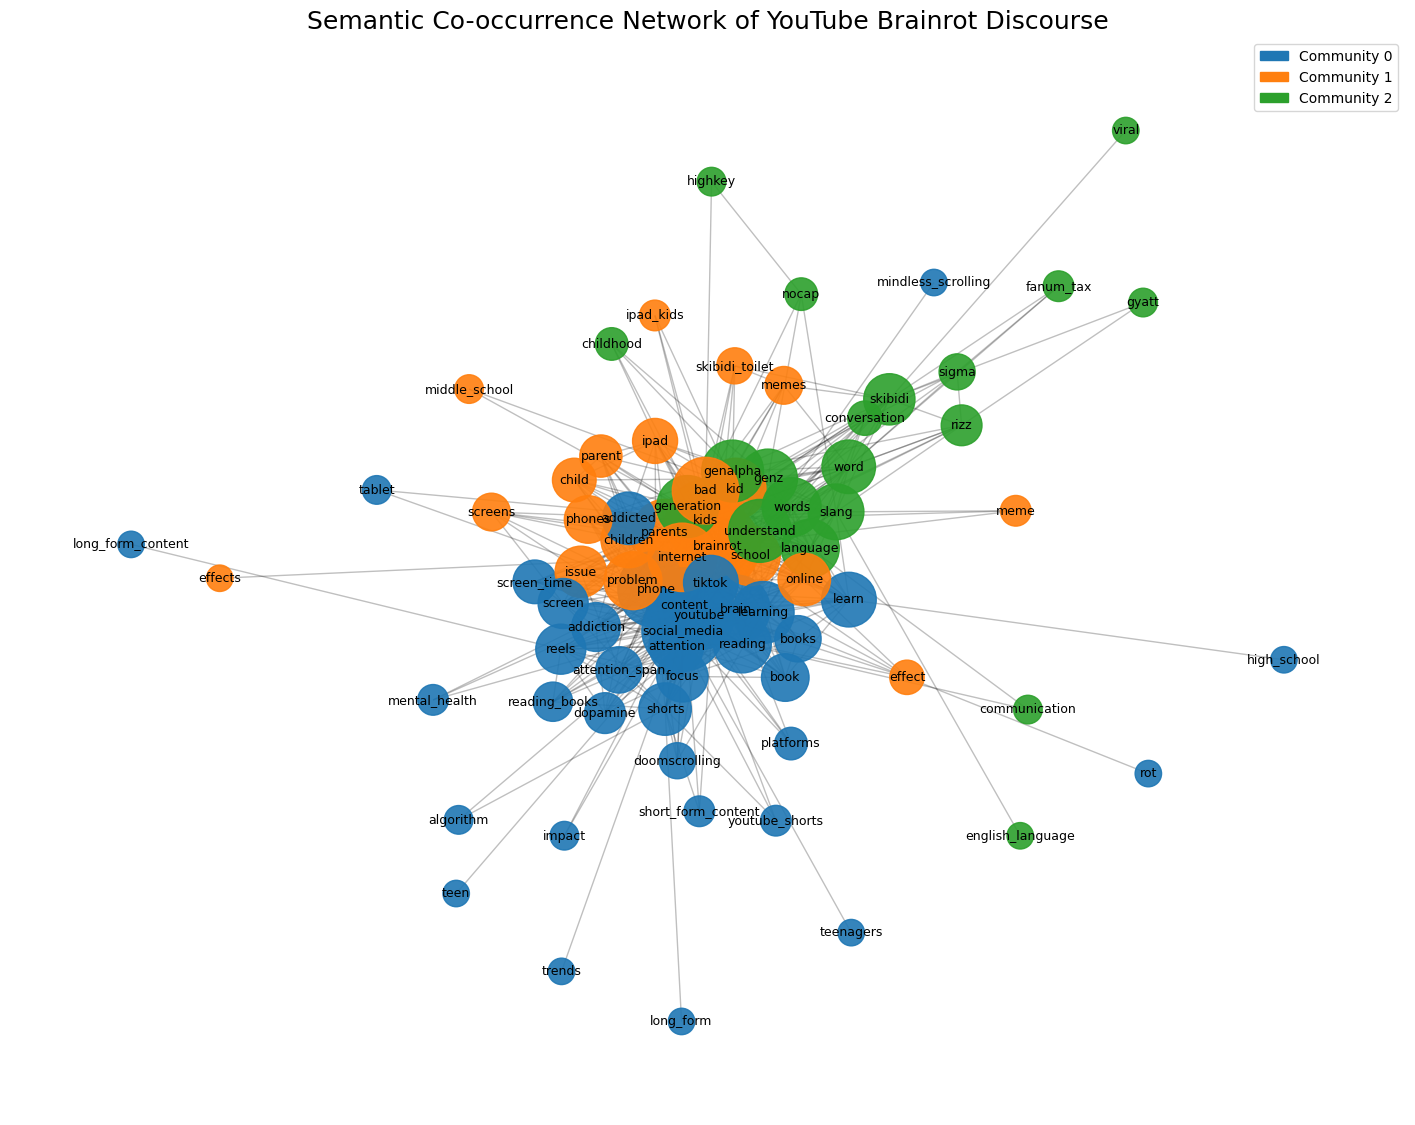

In [34]:

# PHASE 18: NETWORK VISUALISATION

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


community_map = {}

for community_id, nodes in enumerate(communities):

    for node in nodes:

        community_map[node] = community_id


community_colors = {
    0: "#1f77b4",   # blue
    1: "#ff7f0e",   # orange
    2: "#2ca02c",   # green
    3: "#d62728",   # red
    4: "#9467bd",   # purple
}

node_colors = [
    community_colors.get(community_map[node], "#cccccc")
    for node in G.nodes()
]


node_sizes = [

    300 + degree_centrality[node] * 5000

    for node in G.nodes()

]


# Layout

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.45
)


# Plot


plt.figure(figsize=(18, 14))

# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.25,
    width=1
)

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9
)

# Draw labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)


# Legend


legend_elements = [

    mpatches.Patch(
        color=color,
        label=f"Community {community_id}"
    )

    for community_id, color in community_colors.items()
    if community_id in set(community_map.values())
]

plt.legend(
    handles=legend_elements,
    loc="best"
)

plt.title(
    "Semantic Co-occurrence Network of YouTube Brainrot Discourse",
    fontsize=18
)

plt.axis("off")

plt.show()

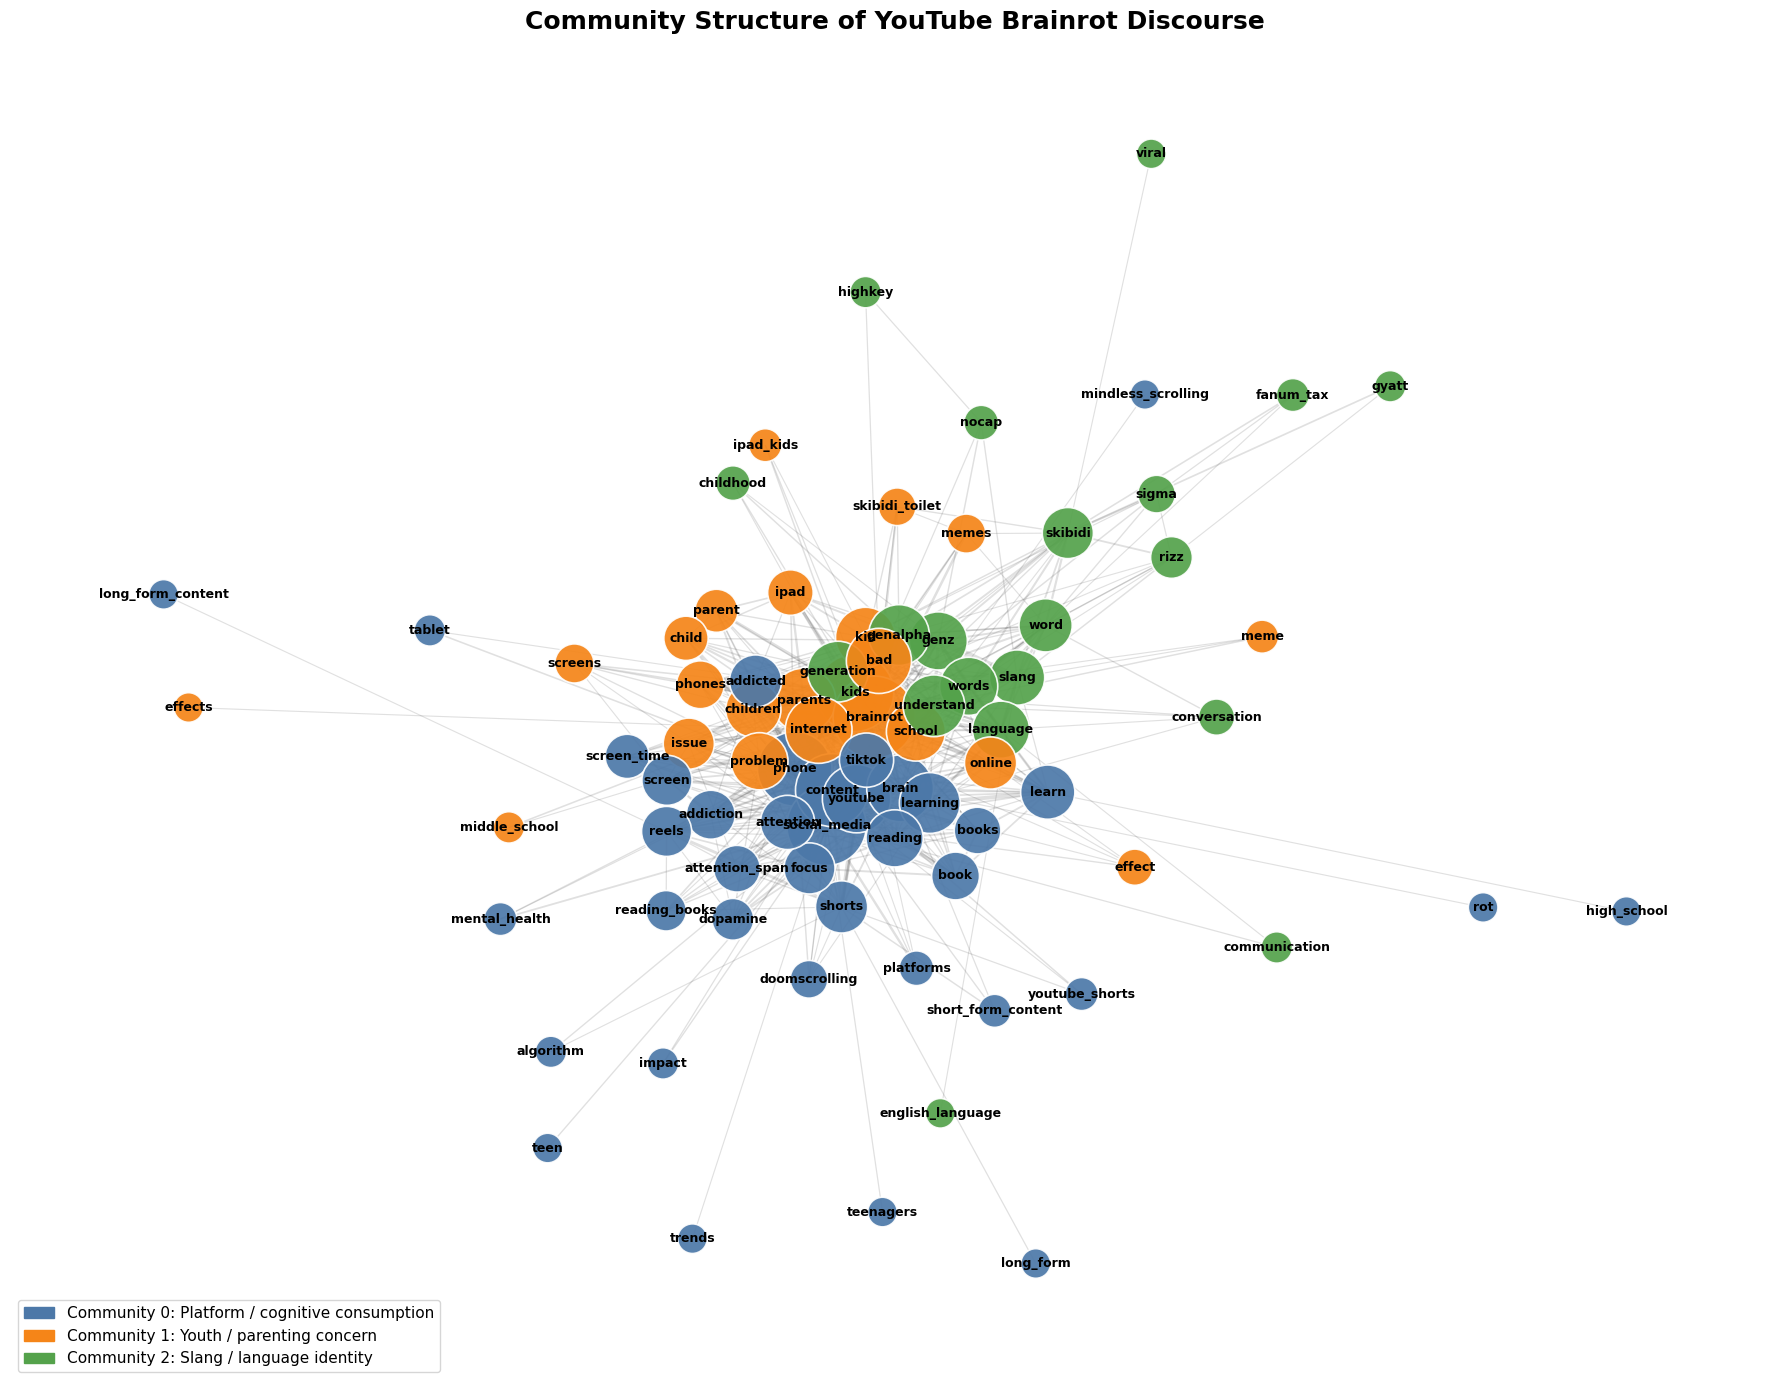

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

community_map = {}

for community_id, nodes in enumerate(communities):
    for node in nodes:
        community_map[node] = community_id

community_colors = {
    0: "#4C78A8",
    1: "#F58518",
    2: "#54A24B"
}

node_colors = [
    community_colors.get(community_map[node], "#cccccc")
    for node in G.nodes()
]

node_sizes = [
    400 + degree_centrality[node] * 4500
    for node in G.nodes()
]

edge_widths = [
    0.4 + G[u][v]["weight"] / 12
    for u, v in G.edges()
]

pos = nx.spring_layout(G, seed=42, k=0.55)

plt.figure(figsize=(18, 14))

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.18,
    edge_color="#555555"
)

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.92,
    linewidths=1.2,
    edgecolors="white"
)

nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_weight="bold"
)

legend_elements = [
    mpatches.Patch(color="#4C78A8", label="Community 0: Platform / cognitive consumption"),
    mpatches.Patch(color="#F58518", label="Community 1: Youth / parenting concern"),
    mpatches.Patch(color="#54A24B", label="Community 2: Slang / language identity")
]

plt.legend(handles=legend_elements, loc="lower left", fontsize=11)

plt.title(
    "Community Structure of YouTube Brainrot Discourse",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.savefig("network_community_structure.png", dpi=300, bbox_inches="tight")
plt.show()

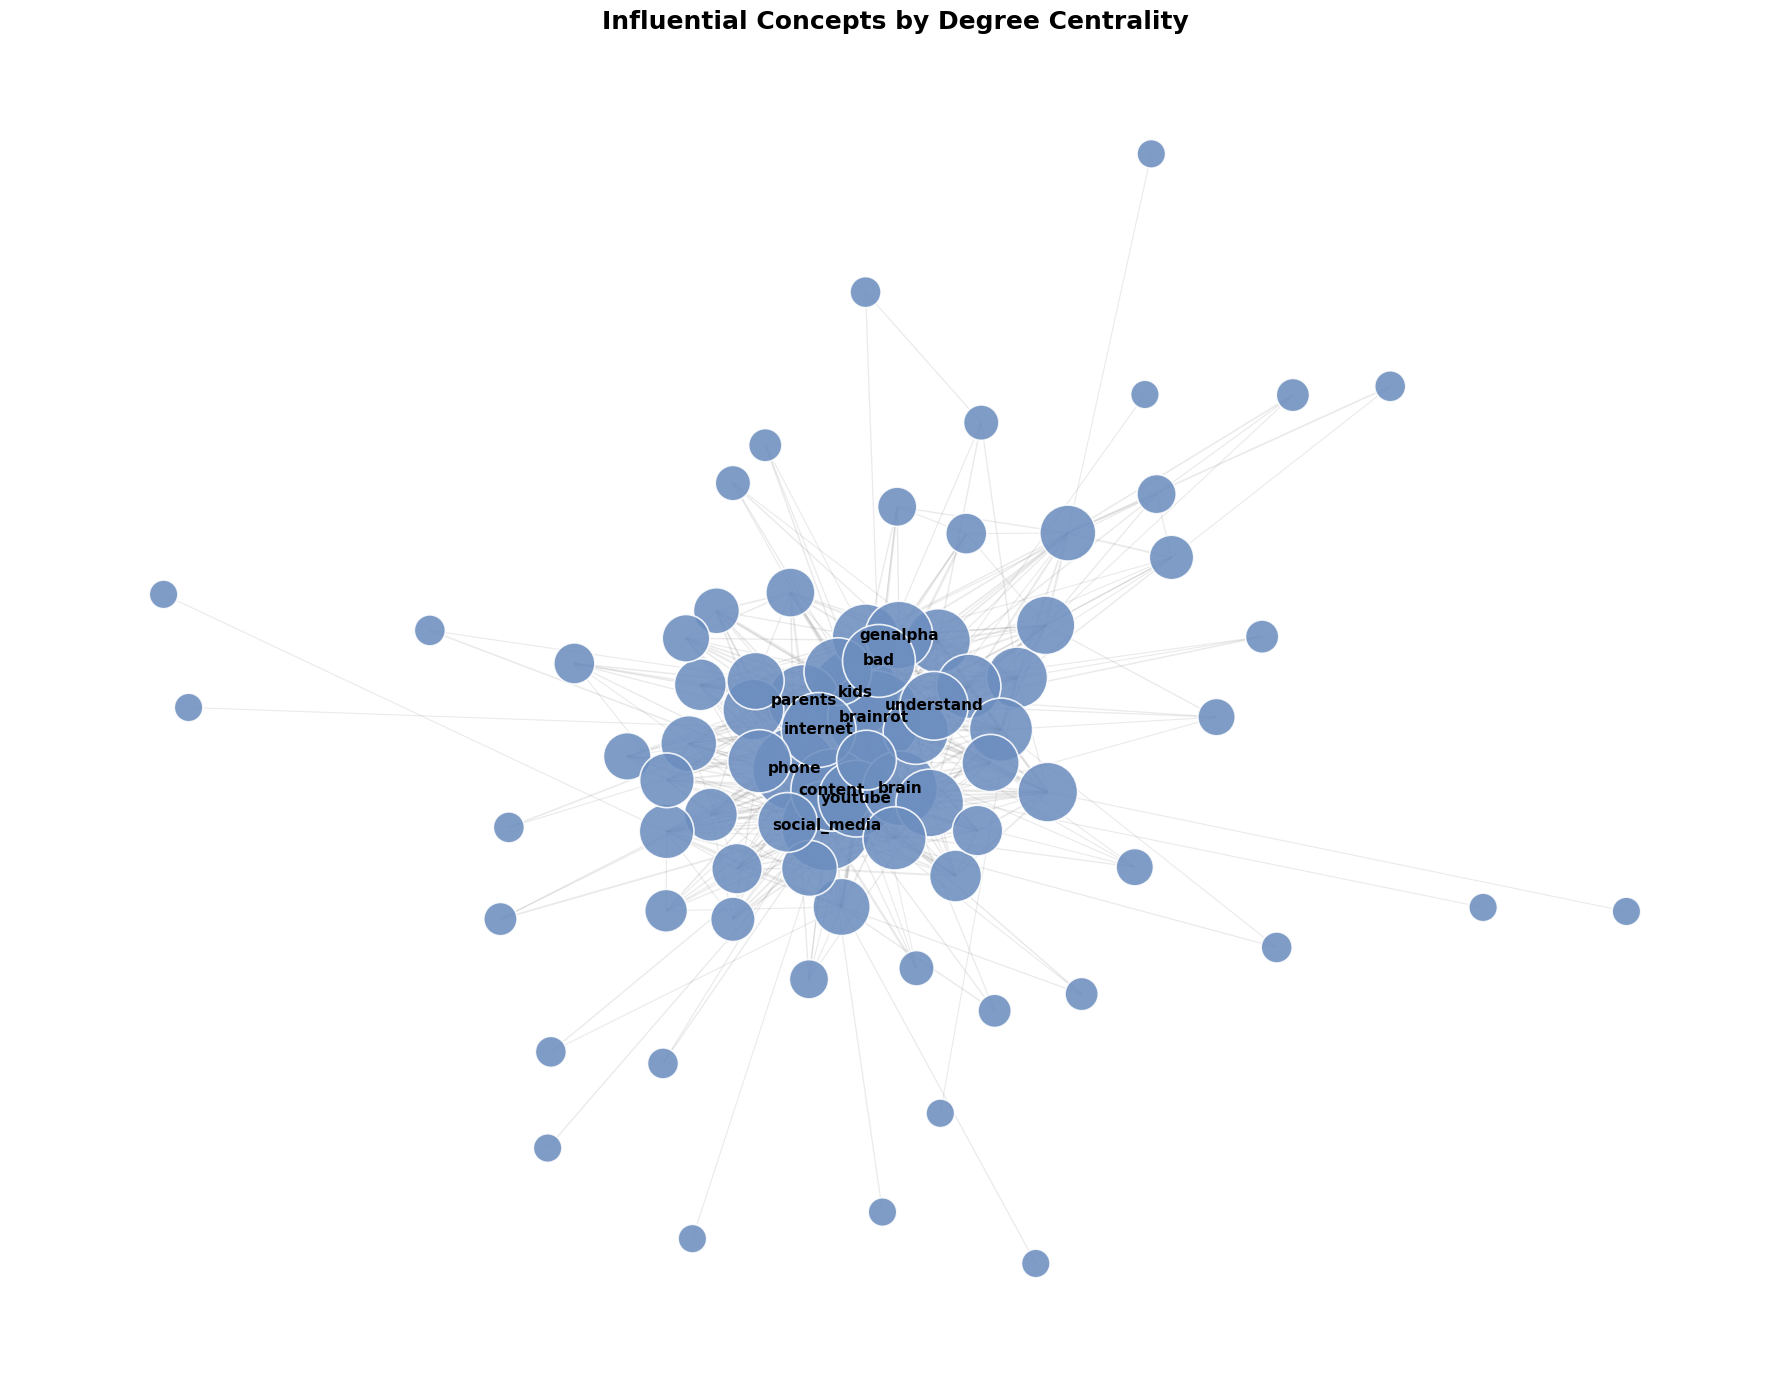

In [36]:
node_sizes_degree = [
    350 + degree_centrality[node] * 6000
    for node in G.nodes()
]

top_degree_nodes = set(degree_df.head(12)["concept"])

label_dict = {
    node: node
    for node in G.nodes()
    if node in top_degree_nodes
}

plt.figure(figsize=(18, 14))

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.15,
    edge_color="#777777"
)

nx.draw_networkx_nodes(
    G, pos,
    node_color="#6C8EBF",
    node_size=node_sizes_degree,
    alpha=0.88,
    linewidths=1.2,
    edgecolors="white"
)

nx.draw_networkx_labels(
    G, pos,
    labels=label_dict,
    font_size=11,
    font_weight="bold"
)

plt.title(
    "Influential Concepts by Degree Centrality",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.savefig("network_degree_centrality.png", dpi=300, bbox_inches="tight")
plt.show()

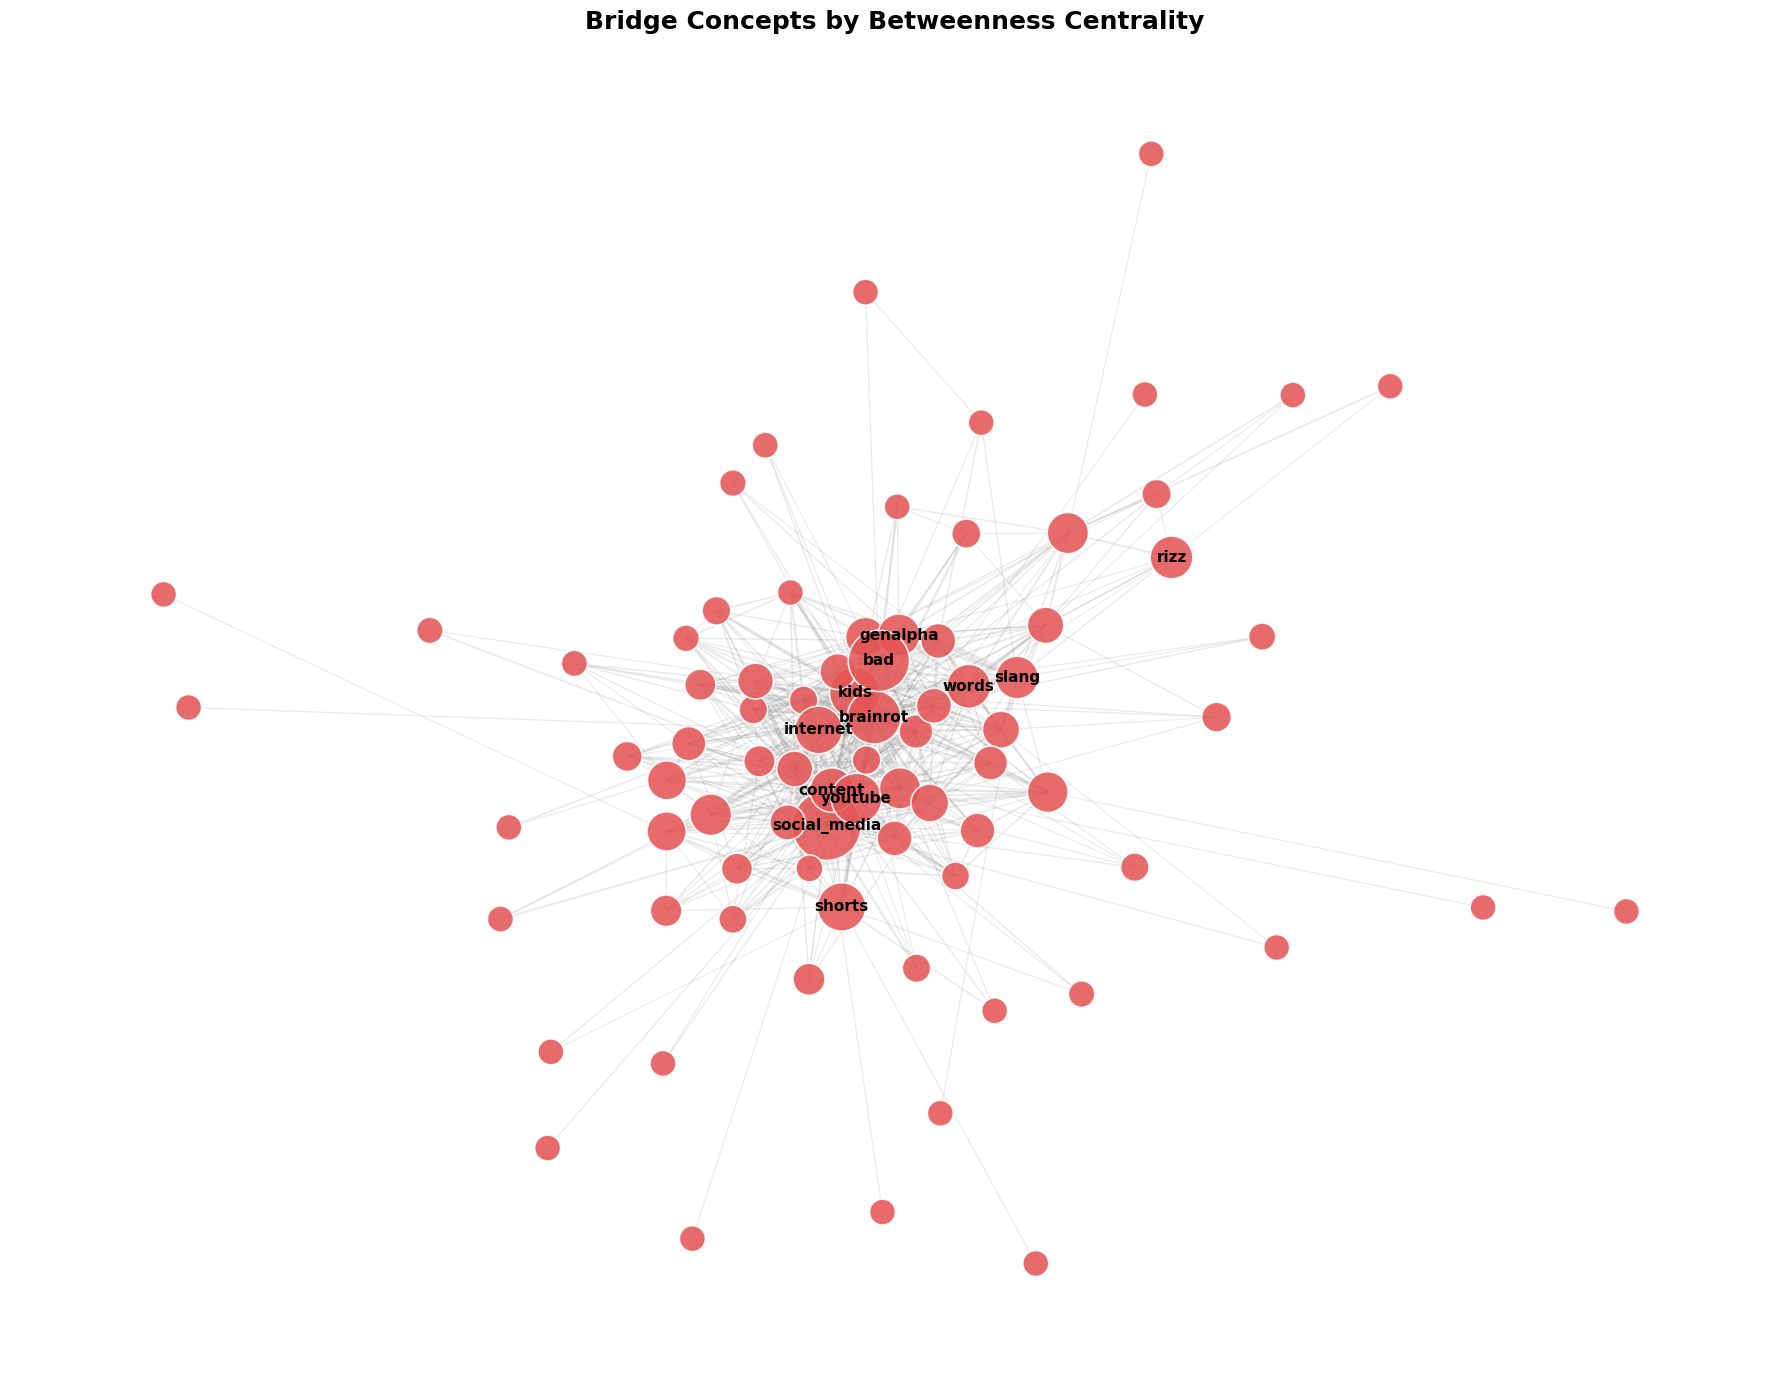

In [37]:
node_sizes_betweenness = [
    350 + betweenness_centrality[node] * 16000
    for node in G.nodes()
]

top_betweenness_nodes = set(betweenness_df.head(12)["concept"])

label_dict = {
    node: node
    for node in G.nodes()
    if node in top_betweenness_nodes
}

plt.figure(figsize=(18, 14))

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.15,
    edge_color="#777777"
)

nx.draw_networkx_nodes(
    G, pos,
    node_color="#E45756",
    node_size=node_sizes_betweenness,
    alpha=0.88,
    linewidths=1.2,
    edgecolors="white"
)

nx.draw_networkx_labels(
    G, pos,
    labels=label_dict,
    font_size=11,
    font_weight="bold"
)

plt.title(
    "Bridge Concepts by Betweenness Centrality",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.savefig("network_betweenness_centrality.png", dpi=300, bbox_inches="tight")
plt.show()